In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the cleaned dataset
df = pd.read_csv('Cleaning_data_merged.csv')
print(f"Dataset loaded: {df.shape}")
print(f"\nRelevant columns for diabetes classification:")
print(f"  DIQ010: {df['DIQ010'].notna().sum()} non-null values")
print(f"  DIQ160: {df['DIQ160'].notna().sum()} non-null values")
print(f"  LBXGH:  {df['LBXGH'].notna().sum()} non-null values")


Dataset loaded: (11933, 98)

Relevant columns for diabetes classification:
  DIQ010: 11740 non-null values
  DIQ160: 8022 non-null values
  LBXGH:  6715 non-null values


In [4]:
# Initialize new category column
df['diagnostic_category'] = 'Unclassified'

# ============================================================================
# 1. ABSOLUTE DIAGNOSED DIABETES
# DIQ010 = 1 (Yes) & LBXGH ≥ 6.5
# ============================================================================
absolute_diagnosed = (df['DIQ010'] == 1.0) & (df['LBXGH'] >= 6.5)
df.loc[absolute_diagnosed, 'diagnostic_category'] = 'Absolute Diagnosed Diabetes'
print(f"Absolute Diagnosed Diabetes: {absolute_diagnosed.sum()}")

# ============================================================================
# 2. ABSOLUTE DIAGNOSED PRE-DIABETES
# DIQ160 = 1 (Yes) & LBXGH between 5.7-6.49
# ============================================================================
absolute_prediabetes = (df['DIQ160'] == 1.0) & (df['LBXGH'] >= 5.7) & (df['LBXGH'] < 6.5)
df.loc[absolute_prediabetes, 'diagnostic_category'] = 'Absolute Diagnosed Pre-Diabetes'
print(f"Absolute Diagnosed Pre-Diabetes: {absolute_prediabetes.sum()}")

# ============================================================================
# 3. ABSOLUTE NO DIABETES
# (DIQ010 = 2 (No) & LBXGH < 5.7) OR (DIQ160 = 2 (No) & LBXGH < 5.7)
# ============================================================================
absolute_no_diabetes = ((df['DIQ010'] == 2.0) & (df['LBXGH'] < 5.7)) | \
                       ((df['DIQ160'] == 2.0) & (df['LBXGH'] < 5.7))
df.loc[absolute_no_diabetes, 'diagnostic_category'] = 'Absolute No Diabetes'
print(f"Absolute No Diabetes: {absolute_no_diabetes.sum()}")

# ============================================================================
# 4. WRONGLY DIAGNOSED (Misclassification/Discordance)
# Multiple conditions for diagnostic mismatch
# ============================================================================
wrongly_diagnosed = (
    # DIQ010 = 1 (YES) & LBXGH < 6.5 (diagnosed but no biomarker evidence)
    ((df['DIQ010'] == 1.0) & (df['LBXGH'] < 6.5)) |
    # DIQ010 = 2 (No) & LBXGH > 5.7 (denies diabetes but has biomarker)
    ((df['DIQ010'] == 2.0) & (df['LBXGH'] > 6.5)) |
    # DIQ010 = 3 (Borderline) & (LBXGH < 5.7 OR LBXGH > 6.49) (uncertain with mismatched biomarker)
    ((df['DIQ010'] == 3.0) & ((df['LBXGH'] < 5.7) | (df['LBXGH'] > 6.49))) |
    # DIQ160 = 1 (YES) & (LBXGH < 5.7 OR LBXGH > 6.49) (pre-diabetes reported but biomarker mismatches)
    ((df['DIQ160'] == 1.0) & ((df['LBXGH'] < 5.7) | (df['LBXGH'] > 6.49))) |
    # DIQ160 = 2 (No) & LBXGH > 5.7 (denies pre-diabetes but has elevated HbA1c)
    ((df['DIQ160'] == 2.0) & ((df['LBXGH'] >= 5.7) | (df['LBXGH'] < 6.49) ))
)
df.loc[wrongly_diagnosed, 'diagnostic_category'] = 'Wrongly Diagnosed'
print(f"Wrongly Diagnosed: {wrongly_diagnosed.sum()}")

print("\n" + "=" * 70)
print("Diagnostic Categories Created")
print("=" * 70)
print(f"\nCategory Distribution:")
print(df['diagnostic_category'].value_counts())
print(f"\nProportions:")
print(df['diagnostic_category'].value_counts(normalize=True).round(4))


Absolute Diagnosed Diabetes: 569
Absolute Diagnosed Pre-Diabetes: 366
Absolute No Diabetes: 4222
Wrongly Diagnosed: 5646

Diagnostic Categories Created

Category Distribution:
diagnostic_category
Wrongly Diagnosed                  5646
Unclassified                       5343
Absolute Diagnosed Diabetes         569
Absolute Diagnosed Pre-Diabetes     366
Absolute No Diabetes                  9
Name: count, dtype: int64

Proportions:
diagnostic_category
Wrongly Diagnosed                  0.4731
Unclassified                       0.4477
Absolute Diagnosed Diabetes        0.0477
Absolute Diagnosed Pre-Diabetes    0.0307
Absolute No Diabetes               0.0008
Name: proportion, dtype: float64


In [5]:
# Check for overlaps and unclassified records
print("=" * 70)
print("VALIDATION CHECK")
print("=" * 70)

unclassified = (df['diagnostic_category'] == 'Unclassified').sum()
print(f"\nUnclassified records: {unclassified:,}")

if unclassified > 0:
    print("\nSample of unclassified records:")
    print(df[df['diagnostic_category'] == 'Unclassified'][['DIQ010', 'DIQ160', 'LBXGH', 'diagnostic_category']].head(10))

# Verify no overlaps (each row should have exactly one category)
total = len(df)
categorized = (df['diagnostic_category'] != 'Unclassified').sum()
print(f"\nTotal records: {total:,}")
print(f"Categorized: {categorized:,}")
print(f"Coverage: {100*categorized/total:.1f}%")

VALIDATION CHECK

Unclassified records: 5,343

Sample of unclassified records:
    DIQ010  DIQ160  LBXGH diagnostic_category
3      2.0     NaN    NaN        Unclassified
4      2.0     NaN    NaN        Unclassified
5      2.0     NaN    NaN        Unclassified
6      2.0     2.0    NaN        Unclassified
7      2.0     1.0    NaN        Unclassified
23     2.0     2.0    NaN        Unclassified
27     2.0     NaN    NaN        Unclassified
32     2.0     2.0    NaN        Unclassified
33     2.0     NaN    NaN        Unclassified
34     2.0     NaN    NaN        Unclassified

Total records: 11,933
Categorized: 6,590
Coverage: 55.2%


In [6]:
# Remove Unclassified records
print("=" * 70)
print("REMOVING UNCLASSIFIED RECORDS")
print("=" * 70)

before_count = len(df)
df = df[df['diagnostic_category'] != 'Unclassified'].copy()
after_count = len(df)
removed = before_count - after_count

print(f"\nBefore: {before_count:,} records")
print(f"After:  {after_count:,} records")
print(f"Removed: {removed:,} records ({100*removed/before_count:.2f}%)")

print("\nFinal Category Distribution:")
print(df['diagnostic_category'].value_counts())
print(f"\nFinal Proportions:")
print(df['diagnostic_category'].value_counts(normalize=True).round(4))

REMOVING UNCLASSIFIED RECORDS

Before: 11,933 records
After:  6,590 records
Removed: 5,343 records (44.77%)

Final Category Distribution:
diagnostic_category
Wrongly Diagnosed                  5646
Absolute Diagnosed Diabetes         569
Absolute Diagnosed Pre-Diabetes     366
Absolute No Diabetes                  9
Name: count, dtype: int64

Final Proportions:
diagnostic_category
Wrongly Diagnosed                  0.8568
Absolute Diagnosed Diabetes        0.0863
Absolute Diagnosed Pre-Diabetes    0.0555
Absolute No Diabetes               0.0014
Name: proportion, dtype: float64


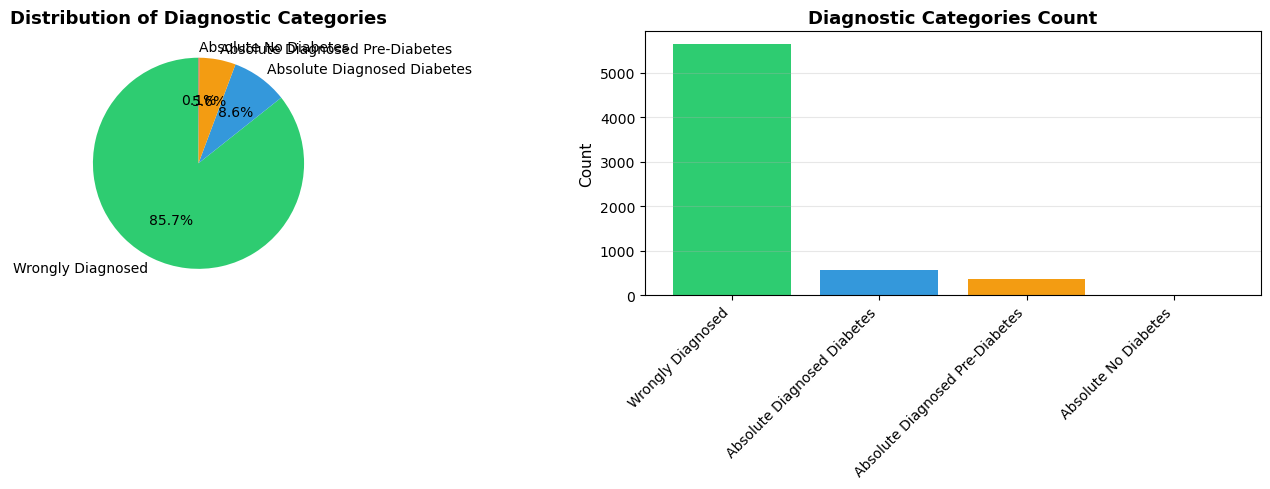


Summary Statistics:
  Wrongly Diagnosed: 5,646 (85.68%)
  Absolute Diagnosed Pre-Diabetes: 366 (5.55%)
  Absolute Diagnosed Diabetes: 569 (8.63%)
  Absolute No Diabetes: 9 (0.14%)


In [10]:
# Visualize the distribution with pie chart and bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
category_counts = df['diagnostic_category'].value_counts()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']
ax1.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', 
        colors=colors[:len(category_counts)], startangle=90)
ax1.set_title('Distribution of Diagnostic Categories', fontsize=13, fontweight='bold')

# Bar chart
ax2.bar(range(len(category_counts)), category_counts.values, color=colors[:len(category_counts)])
ax2.set_xticks(range(len(category_counts)))
ax2.set_xticklabels(category_counts.index, rotation=45, ha='right')
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Diagnostic Categories Count', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSummary Statistics:")
for category in df['diagnostic_category'].unique():
    count = (df['diagnostic_category'] == category).sum()
    pct = 100 * count / len(df)
    print(f"  {category}: {count:,} ({pct:.2f}%)")